In [73]:
# House price prediction using random forest
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import cross_validate

In [74]:
# 1) Load data set
df = pd.read_csv(r"HousePrice.csv")

In [75]:
print ("First Five Rows: ")
print (df.head())

print ("\nDataset shape: ")
print (df.shape)

print ("\nColumn Name: ")
print (df.columns.tolist())

print ("\nData type: ")
print (df.dtypes)

print ("\nMissing values: ")
print (df.isnull().sum())

print ("\nDuplicate Rows: ")
print (df.duplicated().sum())

First Five Rows: 
           id   Date  number of bedrooms  number of bathrooms  living area  \
0  6762810145  42491                   5                 2.50         3650   
1  6762810635  42491                   4                 2.50         2920   
2  6762810998  42491                   5                 2.75         2910   
3  6762812605  42491                   4                 2.50         3310   
4  6762812919  42491                   3                 2.00         2710   

   lot area  number of floors  waterfront present  number of views  \
0      9050               2.0                   0                4   
1      4000               1.5                   0                0   
2      9480               1.5                   0                0   
3     42998               2.0                   0                0   
4      4500               1.5                   0                0   

   condition of the house  ...  Built Year  Renovation Year  Postal Code  \
0               

In [76]:
# 2) Eploratory Data Analysis (EDA)

print ("Statistical summary:")
print (df.describe())

Statistical summary:
                 id          Date  number of bedrooms  number of bathrooms  \
count  1.462000e+04  14620.000000        14620.000000         14620.000000   
mean   6.762821e+09  42604.538646            3.379343             2.129583   
std    6.237575e+03     67.347991            0.938719             0.769934   
min    6.762810e+09  42491.000000            1.000000             0.500000   
25%    6.762815e+09  42546.000000            3.000000             1.750000   
50%    6.762821e+09  42600.000000            3.000000             2.250000   
75%    6.762826e+09  42662.000000            4.000000             2.500000   
max    6.762832e+09  42734.000000           33.000000             8.000000   

        living area      lot area  number of floors  waterfront present  \
count  14620.000000  1.462000e+04      14620.000000        14620.000000   
mean    2098.262996  1.509328e+04          1.502360            0.007661   
std      928.275721  3.791962e+04          0.540239

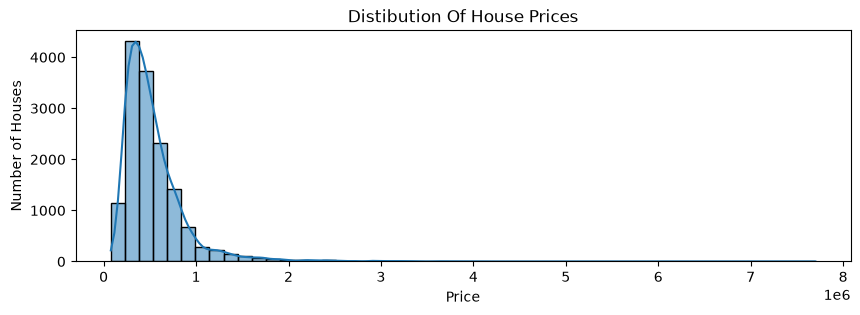

In [77]:
# Distribuion of house prices

plt.figure(figsize=(10, 3))

sns.histplot(df["Price"], bins=50, kde=True)

plt.title("Distibution Of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

In [78]:
# Correlation of all numerical features with price
correlation = df.corr(numeric_only=True)["Price"].sort_values(ascending=False)

print("Correlation with price:")
print(correlation)

Correlation with price:
Price                                    1.000000
living area                              0.712169
grade of the house                       0.671814
Area of the house(excluding basement)    0.615220
living_area_renov                        0.584924
number of bathrooms                      0.531735
number of views                          0.395973
Area of the basement                     0.330202
number of bedrooms                       0.308460
Lattitude                                0.297490
waterfront present                       0.263687
number of floors                         0.262732
Renovation Year                          0.133173
lot area                                 0.081992
lot_area_renov                           0.075535
Built Year                               0.050307
condition of the house                   0.041376
Longitude                                0.024414
Number of schools nearby                 0.009890
Distance from the airport 

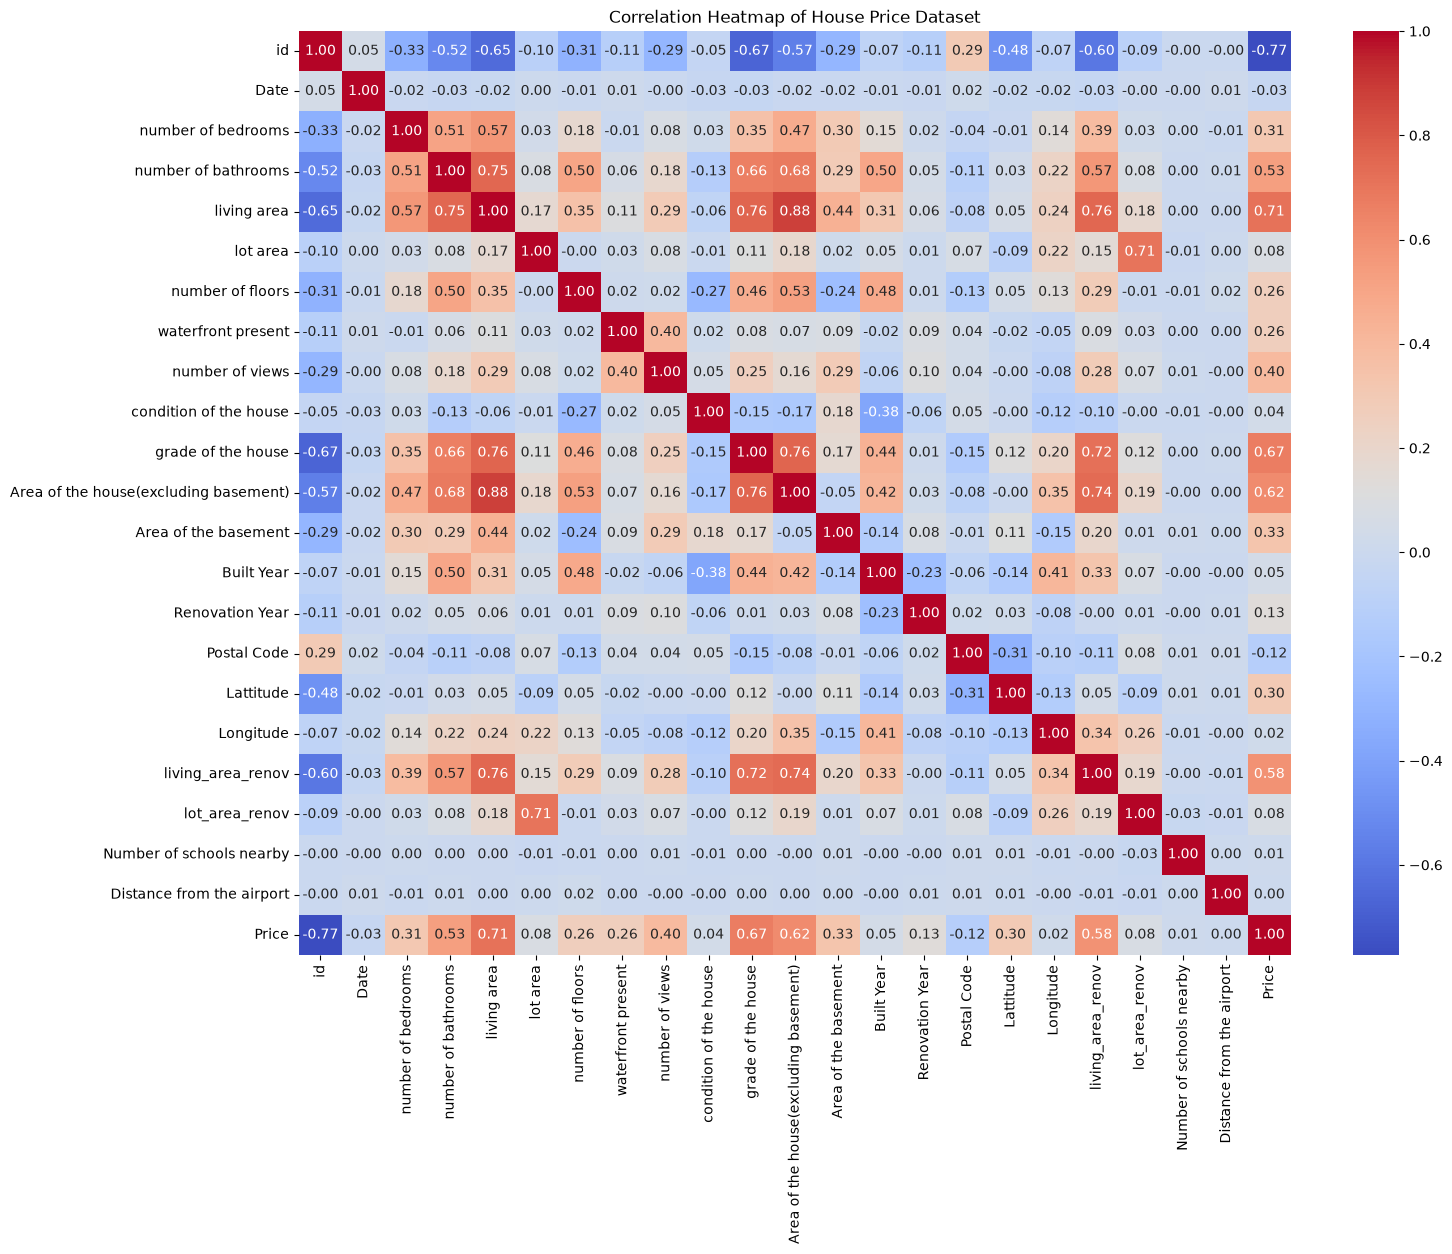

In [79]:
# Correlation heatmap
plt.figure(figsize=(16, 12))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of House Price Dataset")
plt.show()

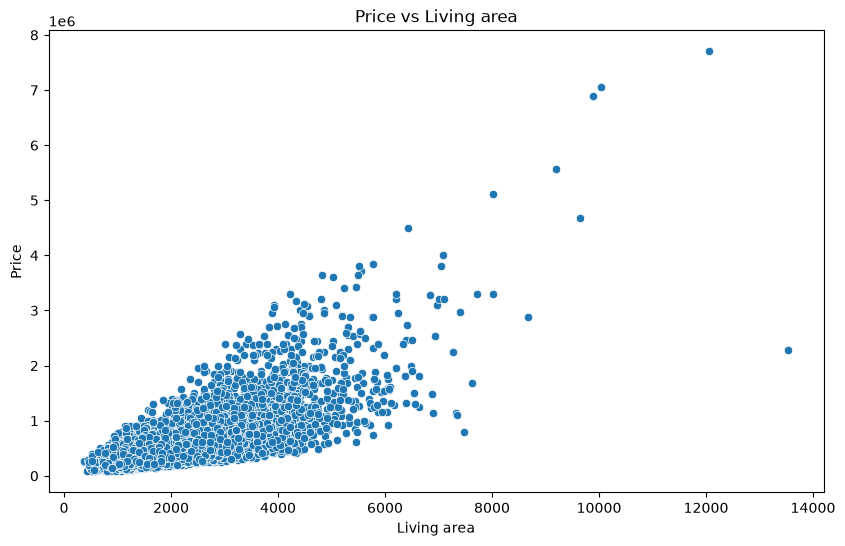

In [80]:
# Price vs Living area
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="living area",
    y="Price"
)

plt.title("Price vs Living area")
plt.xlabel("Living area")
plt.ylabel("Price")
plt.show()

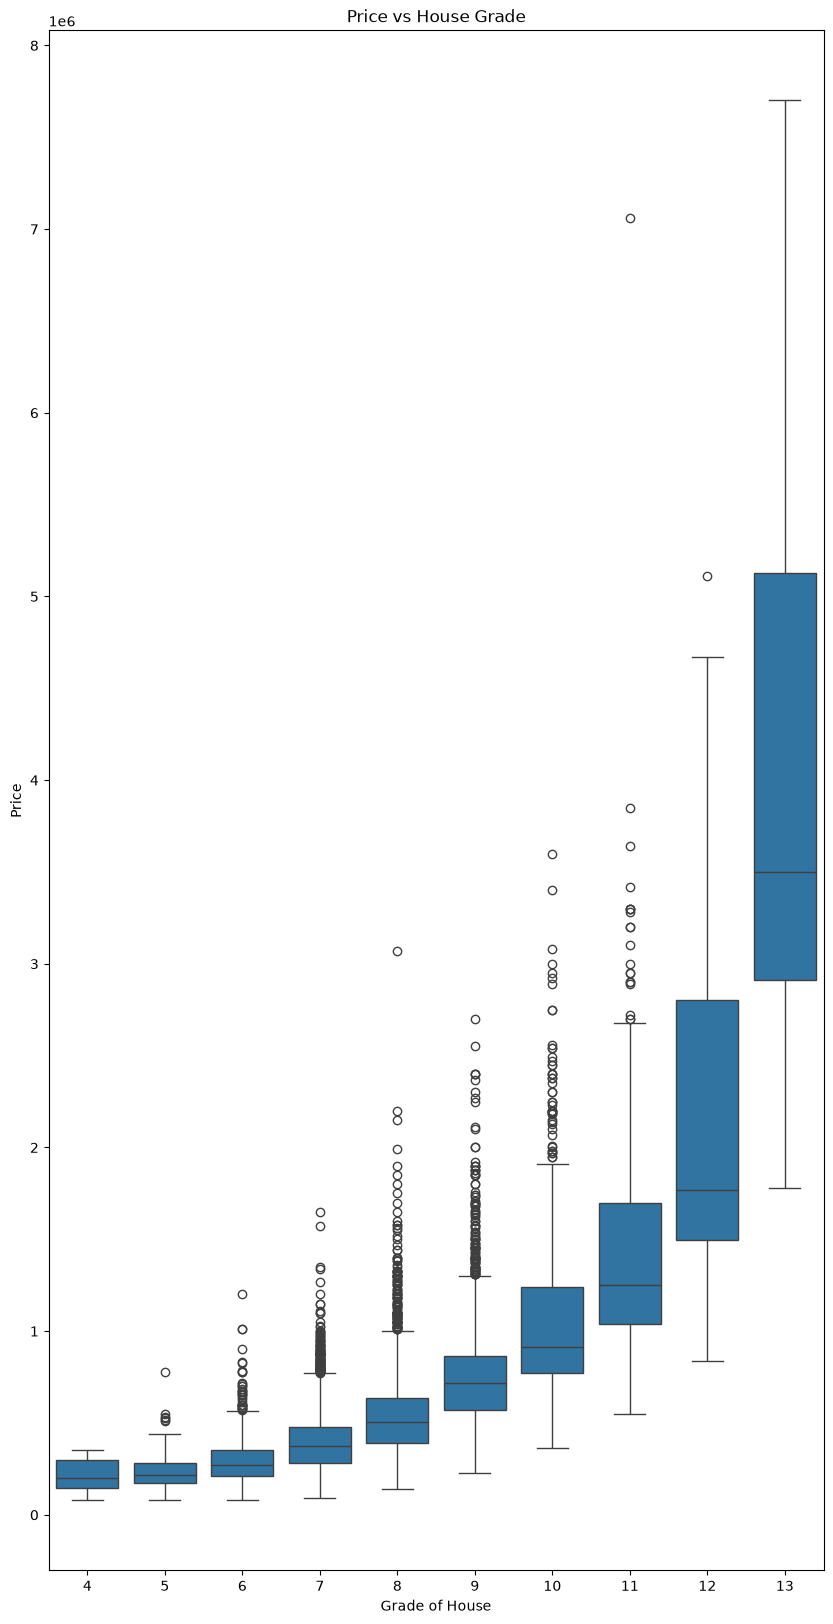

In [81]:
# Price vs Grade
plt.figure(figsize=(10, 20))

sns.boxplot(
    data=df,
    x="grade of the house",
    y="Price"
)

plt.title("Price vs House Grade")
plt.xlabel("Grade of House")
plt.ylabel("Price")
plt.show()

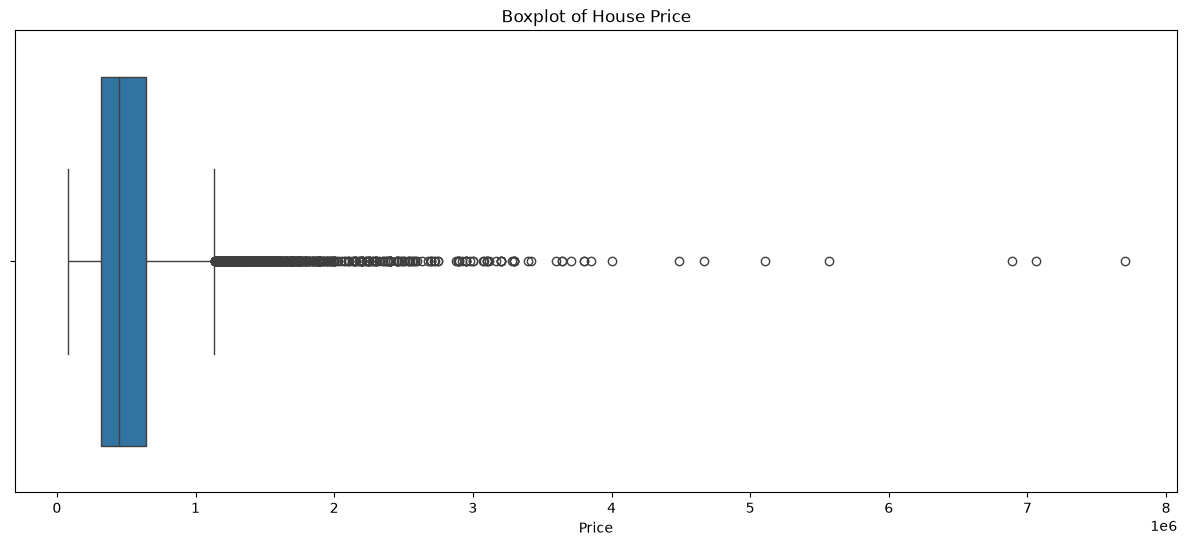

In [82]:
# Check for outliers
# Price vs Living area
plt.figure(figsize=(15, 6))

sns.boxplot(x=df["Price"])
    

plt.title("Boxplot of House Price")
plt.xlabel("Price")
plt.show()

In [83]:
# Check the id colum
print(f"Unique IDs: {df["id"].nunique()}")
print(f"Total Rows: {len(df)}")

Unique IDs: 14620
Total Rows: 14620


In [84]:
# Investigatethe date column
print(f"Date Column: {df["Date"].head(10)}")

Date Column: 0    42491
1    42491
2    42491
3    42491
4    42491
5    42491
6    42491
7    42491
8    42491
9    42491
Name: Date, dtype: int64


In [85]:
# Convert Excel serial date to actual date
df["Sale_Date"] = pd.to_datetime(
    df["Date"],
    origin="1899-12-30",
    unit="D",
)

print(df[["Date", "Sale_Date"]].head())

    Date  Sale_Date
0  42491 2016-05-01
1  42491 2016-05-01
2  42491 2016-05-01
3  42491 2016-05-01
4  42491 2016-05-01


In [86]:
# Extract (Day/Month/Year)
df["Sale_Year"] = df["Sale_Date"].dt.year
df["Sale_Month"] = df["Sale_Date"].dt.month

print (df[["Sale_Date", "Sale_Year", "Sale_Month"]].head())

   Sale_Date  Sale_Year  Sale_Month
0 2016-05-01       2016           5
1 2016-05-01       2016           5
2 2016-05-01       2016           5
3 2016-05-01       2016           5
4 2016-05-01       2016           5


In [87]:
# Check for missing values
missing_values = df.isnull().sum()
print(f"Missing Values: {missing_values[missing_values > 0]}")

Missing Values: Series([], dtype: int64)


In [88]:
# 3) Data cleaning and remove useless information
df = df.drop("id", axis=1)                       # no need for the id 
df = df.drop(["Date", "Sale_Date"], axis=1)      # no need for excel dates

print (f"Dataset after initial cleaning: {df.head()}")
print (f"\nNew shape: {df.shape}")
print (f"\nColumns: {df.columns.tolist()}")

Dataset after initial cleaning:    number of bedrooms  number of bathrooms  living area  lot area  \
0                   5                 2.50         3650      9050   
1                   4                 2.50         2920      4000   
2                   5                 2.75         2910      9480   
3                   4                 2.50         3310     42998   
4                   3                 2.00         2710      4500   

   number of floors  waterfront present  number of views  \
0               2.0                   0                4   
1               1.5                   0                0   
2               1.5                   0                0   
3               2.0                   0                0   
4               1.5                   0                0   

   condition of the house  grade of the house  \
0                       5                  10   
1                       5                   8   
2                       3                   8

In [89]:
# Features vs Target
X = df.drop("Price", axis=1)
y = df["Price"]

print(f"Features (X): \n{X.head()}")
print(f"\nTarget (y): \n{y.head()}")
print(f"\nShape (X): {X.shape}")
print(f"\nShape (y): {y.shape}")

Features (X): 
   number of bedrooms  number of bathrooms  living area  lot area  \
0                   5                 2.50         3650      9050   
1                   4                 2.50         2920      4000   
2                   5                 2.75         2910      9480   
3                   4                 2.50         3310     42998   
4                   3                 2.00         2710      4500   

   number of floors  waterfront present  number of views  \
0               2.0                   0                4   
1               1.5                   0                0   
2               1.5                   0                0   
3               2.0                   0                0   
4               1.5                   0                0   

   condition of the house  grade of the house  \
0                       5                  10   
1                       5                   8   
2                       3                   8   
3            

In [90]:
# Splet Data to Train and Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42
)

# Check the split
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (11696, 22)
Testing Features: (2924, 22)
Training Target: (11696,)
Testing Target: (2924,)


In [91]:
# 4) Baseline Random Forest Rgression Model (First)
model = RandomForestRegressor(
    n_estimators=200,          # 200 decision trees and use there results
    random_state=42,
    n_jobs=-1                  # this allows scikit_to use maximum CPU
)

print("Training Random Forest Model ... ")
model.fit(X_train, y_train)
print("Training copmleted!")

Training Random Forest Model ... 
Training copmleted!


In [92]:
# Make predictions on the test data
y_pred = model.predict(X_test)
print(f"predictions: {y_pred[:10]}")

predictions: [292676.9   622460.155 573112.19  577762.185 579494.235 263121.78
 899920.2   481283.87  912877.64  415502.965]


In [93]:
# Compare predictions with actual prices
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred 
})

print(f"Actual vs Predicted Prices: {comparison.head(10)}")

Actual vs Predicted Prices:    Actual Price  Predicted Price
0        235000       292676.900
1        552000       622460.155
2        615000       573112.190
3        555000       577762.185
4        649950       579494.235
5        257700       263121.780
6        980000       899920.200
7        535000       481283.870
8       1030000       912877.640
9        549950       415502.965


In [94]:
# 5) Model Evaluation: Calculate evaluation matrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("========== MODEL PERFORMANCE ==========")

print(f"R² Score: {r2:.4f}")
print(f"R² Score (%): {r2 * 100:.2f}%")

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

print("========================================")

========== MODEL PERFORMANCE ==========
R² Score: 0.8747
R² Score (%): 87.47%
MAE: 68636.02
MSE: 17660748550.08
RMSE: 132893.75


In [ ]:
# 6) Analyze Feature Importance (most important feature according to the model)
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

# Sort importance in decinding order
feature_importance = feature_importance.sort_values(
    by = "Importance",
    ascending = False
)

print(f"Feature Importance: {feature_importance}")

Feature Importance:                                   Feature  Importance
2                             living area    0.346629
8                      grade of the house    0.232991
14                              Lattitude    0.151355
15                              Longitude    0.064222
16                      living_area_renov    0.032731
9   Area of the house(excluding basement)    0.031092
5                      waterfront present    0.029990
11                             Built Year    0.020181
13                            Postal Code    0.015709
6                         number of views    0.013062
17                         lot_area_renov    0.012160
3                                lot area    0.011472
1                     number of bathrooms    0.009864
19              Distance from the airport    0.006700
10                   Area of the basement    0.005642
21                             Sale_Month    0.004243
0                      number of bedrooms    0.003268
7       

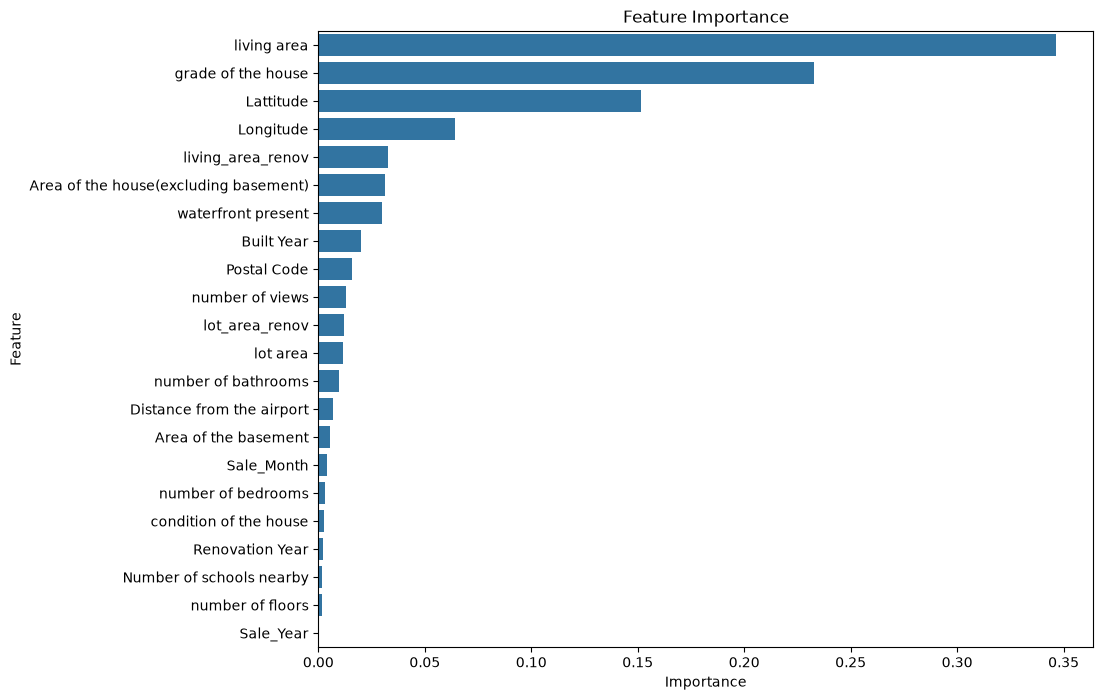

In [96]:
# Visualization of the importance featuers
plt.figure(figsize=(10, 8))

sns.barplot(
    data = feature_importance,
    x = "Importance",
    y = "Feature"
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
# 7) OverFitting check: Calculate R²
y_train_pred = model.predict(X_train)

train_r2 = r2_score(y_train, y_train_pred)

test_r2 = r2_score(y_test, y_pred)

print("========== OVERFITTING CHECK ==========")

print(f"Training R² : {train_r2:.4f}")
print(f"Testing R² : {test_r2:.4f}")

print("========================================")

========== OVERFITTING CHECK ==========
Training R² : 0.9820
Testing R² : 0.8747


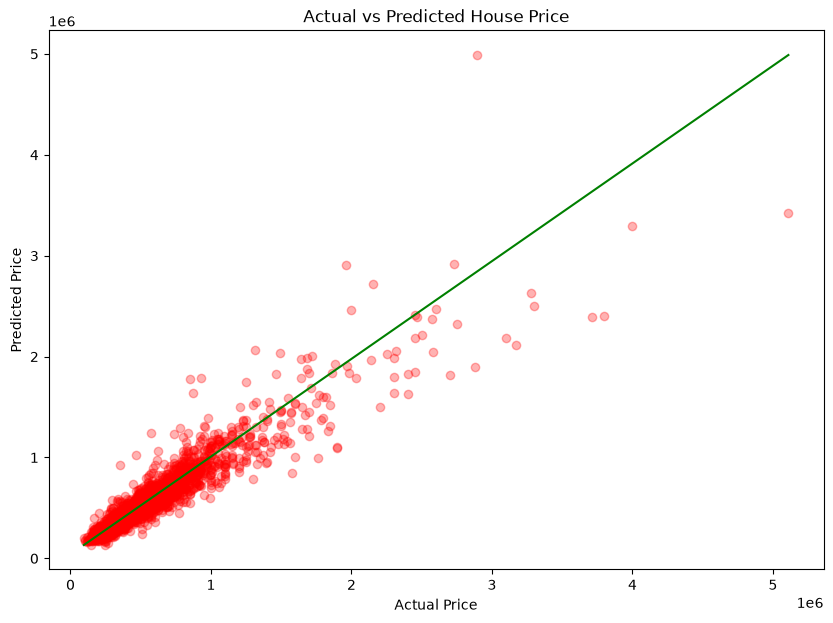

In [ ]:
# 8) Actual vs predicted results visualization
plt.figure(figsize=(10, 7))

# points representing predicted values
plt.scatter(
    y_test,
    y_pred,
    color="red",
    alpha = 0.3
)

# line of actual values
plt.plot(
    [y_test.min(), y_test.max()],
    [y_pred.min(), y_pred.max()],
    color = "green"
)

plt.title("Actual vs Predicted House Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

In [99]:
# 9) Tuning to get rid of overfitting: Hyperarameter tuning
depths = [10, 15, 20, 25]

results = []

for depth in depths:

    print(f"Training model with max_depth = {depth}")

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    # Predictions
    train_pred = rf.predict(X_train)
    test_pred = rf.predict(X_test)

    # Scores
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    results.append({
        "Max Depth": depth,
        "Training R²": train_r2,
        "Testing R²": test_r2,
        "MAE": test_mae,
        "RMSE": test_rmse
    })

results_df = pd.DataFrame(results)

print("========== HYPERPARAMETER RESULTS ==========")
print(results_df)

Training model with max_depth = 10
Training model with max_depth = 15
Training model with max_depth = 20
Training model with max_depth = 25
========== HYPERPARAMETER RESULTS ==========
   Max Depth  Training R²  Testing R²           MAE           RMSE
0         10     0.942627    0.861338  74784.755322  139785.970790
1         15     0.976110    0.873681  69349.704051  133419.569714
2         20     0.981585    0.871955  68873.359697  134327.624816
3         25     0.982011    0.873137  68716.731761  133706.252591


In [100]:
# 10) TUNE min_samples_leaf
leaf_values = [1, 2, 5, 10, 20]

leaf_results = []

for leaf in leaf_values:

    print(f"Training model with min_samples_leaf = {leaf}")

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=leaf,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    # Training predictions
    train_pred = rf.predict(X_train)

    # Testing predictions
    test_pred = rf.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    test_mae = mean_absolute_error(y_test, test_pred)

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    leaf_results.append({
        "Min Samples Leaf": leaf,
        "Training R²": train_r2,
        "Testing R²": test_r2,
        "MAE": test_mae,
        "RMSE": test_rmse
    })

leaf_results_df = pd.DataFrame(leaf_results)

print("========== MIN SAMPLES LEAF RESULTS ==========")
print(leaf_results_df)

Training model with min_samples_leaf = 1
Training model with min_samples_leaf = 2
Training model with min_samples_leaf = 5
Training model with min_samples_leaf = 10
Training model with min_samples_leaf = 20
========== MIN SAMPLES LEAF RESULTS ==========
   Min Samples Leaf  Training R²  Testing R²           MAE           RMSE
0                 1     0.981585    0.871955  68873.359697  134327.624816
1                 2     0.972064    0.870815  69113.303766  134924.678764
2                 5     0.936129    0.872423  70568.687564  134082.381730
3                10     0.888759    0.864065  73387.223274  138404.503747
4                20     0.842750    0.839847  77662.891109  150228.401597


In [101]:
# 11) TUNE min_samples_split

split_values = [2, 5, 10, 20, 50]

split_results = []

for split in split_values:

    print(f"Training model with min_samples_split = {split}")

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=1,
        min_samples_split=split,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    # Training predictions
    train_pred = rf.predict(X_train)

    # Testing predictions
    test_pred = rf.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    test_mae = mean_absolute_error(y_test, test_pred)

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    split_results.append({
        "Min Samples Split": split,
        "Training R²": train_r2,
        "Testing R²": test_r2,
        "MAE": test_mae,
        "RMSE": test_rmse
    })

split_results_df = pd.DataFrame(split_results)

print("========== MIN SAMPLES SPLIT RESULTS ==========")
print(split_results_df)

Training model with min_samples_split = 2
Training model with min_samples_split = 5
Training model with min_samples_split = 10
Training model with min_samples_split = 20
Training model with min_samples_split = 50
========== MIN SAMPLES SPLIT RESULTS ==========
   Min Samples Split  Training R²  Testing R²           MAE           RMSE
0                  2     0.981585    0.871955  68873.359697  134327.624816
1                  5     0.972910    0.873713  68942.431320  133402.485107
2                 10     0.957043    0.875379  69164.002579  132519.618328
3                 20     0.936626    0.872321  70353.864742  134135.617283
4                 50     0.904810    0.861174  73999.892769  139868.743557


In [102]:
# 12) TUNE max_features
max_features_values = [0.5, 0.7, 1.0, "sqrt"]

max_features_results = []

for mf in max_features_values:

    print(f"Training model with max_features = {mf}")

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=1,
        min_samples_split=5,
        max_features=mf,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    # Training predictions
    train_pred = rf.predict(X_train)

    # Testing predictions
    test_pred = rf.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    test_mae = mean_absolute_error(y_test, test_pred)

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    max_features_results.append({
        "Max Features": mf,
        "Training R²": train_r2,
        "Testing R²": test_r2,
        "MAE": test_mae,
        "RMSE": test_rmse
    })

max_features_results_df = pd.DataFrame(max_features_results)

print("========== MAX FEATURES RESULTS ==========")
print(max_features_results_df)

Training model with max_features = 0.5
Training model with max_features = 0.7
Training model with max_features = 1.0
Training model with max_features = sqrt
========== MAX FEATURES RESULTS ==========
  Max Features  Training R²  Testing R²           MAE           RMSE
0          0.5     0.971852    0.873459  69723.507472  133536.552326
1          0.7     0.972776    0.874875  68687.818214  132787.508148
2          1.0     0.972910    0.873713  68942.431320  133402.485107
3         sqrt     0.963777    0.867524  73076.880023  136632.271101


In [103]:
# 13) TUNE n_estimators

n_estimators_values = [100, 200, 300, 500]

n_estimators_results = []

for n in n_estimators_values:

    print(f"Training model with n_estimators = {n}")

    rf = RandomForestRegressor(
        n_estimators=n,
        max_depth=20,
        min_samples_leaf=1,
        min_samples_split=5,
        max_features=0.5,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    # Training predictions
    train_pred = rf.predict(X_train)

    # Testing predictions
    test_pred = rf.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    test_mae = mean_absolute_error(y_test, test_pred)

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    n_estimators_results.append({
        "N Estimators": n,
        "Training R²": train_r2,
        "Testing R²": test_r2,
        "MAE": test_mae,
        "RMSE": test_rmse
    })

n_estimators_results_df = pd.DataFrame(n_estimators_results)

print("========== N ESTIMATORS RESULTS ==========")
print(n_estimators_results_df)

Training model with n_estimators = 100
Training model with n_estimators = 200
Training model with n_estimators = 300
Training model with n_estimators = 500
========== N ESTIMATORS RESULTS ==========
   N Estimators  Training R²  Testing R²           MAE           RMSE
0           100     0.971403    0.873065  70229.259287  133744.585236
1           200     0.971852    0.873459  69723.507472  133536.552326
2           300     0.972325    0.873224  69619.118332  133660.587380
3           500     0.972706    0.875343  69298.429147  132538.959055


In [104]:
# 14) 5-FOLD CROSS-VALIDATION
# Create 5-fold cross-validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# MODEL 1: ORIGINAL BASELINE

baseline_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

baseline_cv_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

print("========== BASELINE CROSS-VALIDATION ==========")

for i, score in enumerate(baseline_cv_scores, start=1):
    print(f"Fold {i} R²: {score:.4f}")

print(f"Average R²: {baseline_cv_scores.mean():.4f}")
print(f"Standard Deviation: {baseline_cv_scores.std():.4f}")

# MODEL 2: TUNED MODEL

tuned_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=1,
    min_samples_split=5,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

tuned_cv_scores = cross_val_score(
    tuned_model,
    X_train,
    y_train,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

print("\n========== TUNED MODEL CROSS-VALIDATION ==========")

for i, score in enumerate(tuned_cv_scores, start=1):
    print(f"Fold {i} R²: {score:.4f}")

print(f"Average R²: {tuned_cv_scores.mean():.4f}")
print(f"Standard Deviation: {tuned_cv_scores.std():.4f}")

# FINAL COMPARISON

print("\n========== FINAL CV COMPARISON ==========")

print(
    f"Baseline Average R²: "
    f"{baseline_cv_scores.mean():.4f}"
)

print(
    f"Tuned Average R²: "
    f"{tuned_cv_scores.mean():.4f}"
)

========== BASELINE CROSS-VALIDATION ==========
Fold 1 R²: 0.8642
Fold 2 R²: 0.8624
Fold 3 R²: 0.8788
Fold 4 R²: 0.8285
Fold 5 R²: 0.8901
Average R²: 0.8648
Standard Deviation: 0.0208

========== TUNED MODEL CROSS-VALIDATION ==========
Fold 1 R²: 0.8611
Fold 2 R²: 0.8553
Fold 3 R²: 0.8805
Fold 4 R²: 0.8462
Fold 5 R²: 0.8859
Average R²: 0.8658
Standard Deviation: 0.0151

========== FINAL CV COMPARISON ==========
Baseline Average R²: 0.8648
Tuned Average R²: 0.8658


In [105]:
# 17) CROSS-VALIDATION WITH MULTIPLE METRICS

baseline_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

scoring = {
    "R2": "r2",
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error"
}

cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring,
    n_jobs=-1
)

# Convert negative error scores to positive values
r2_scores = cv_results["test_R2"]

mae_scores = -cv_results["test_MAE"]

rmse_scores = -cv_results["test_RMSE"]

print("========== BASELINE MULTI-METRIC CROSS-VALIDATION ==========")

print("\nR² Scores:")
for i, score in enumerate(r2_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"Average R²: {r2_scores.mean():.4f}")
print(f"R² Standard Deviation: {r2_scores.std():.4f}")


print("\nMAE Scores:")
for i, score in enumerate(mae_scores, start=1):
    print(f"Fold {i}: {score:,.2f}")

print(f"Average MAE: {mae_scores.mean():,.2f}")
print(f"MAE Standard Deviation: {mae_scores.std():,.2f}")


print("\nRMSE Scores:")
for i, score in enumerate(rmse_scores, start=1):
    print(f"Fold {i}: {score:,.2f}")

print(f"Average RMSE: {rmse_scores.mean():,.2f}")
print(f"RMSE Standard Deviation: {rmse_scores.std():,.2f}")

========== BASELINE MULTI-METRIC CROSS-VALIDATION ==========

R² Scores:
Fold 1: 0.8642
Fold 2: 0.8624
Fold 3: 0.8788
Fold 4: 0.8285
Fold 5: 0.8901
Average R²: 0.8648
R² Standard Deviation: 0.0208

MAE Scores:
Fold 1: 69,498.10
Fold 2: 67,262.16
Fold 3: 72,754.17
Fold 4: 69,102.68
Fold 5: 66,884.07
Average MAE: 69,100.23
MAE Standard Deviation: 2,088.04

RMSE Scores:
Fold 1: 136,226.73
Fold 2: 132,373.84
Fold 3: 136,733.79
Fold 4: 144,904.85
Fold 5: 118,147.33
Average RMSE: 133,677.31
RMSE Standard Deviation: 8,772.44


In [108]:
# 16) COMPARE TRAINING AND TEST PRICE
# DISTRIBUTIONS


print("========== TRAINING PRICE STATISTICS ==========")
print(y_train.describe())

print("========== TEST PRICE STATISTICS ==========")
print(y_test.describe())

========== TRAINING PRICE STATISTICS ==========
count    1.169600e+04
mean     5.377837e+05
std      3.655319e+05
min      7.800000e+04
25%      3.210000e+05
50%      4.500000e+05
75%      6.430005e+05
max      7.700000e+06
Name: Price, dtype: float64
========== TEST PRICE STATISTICS ==========
count    2.924000e+03
mean     5.435262e+05
std      3.754559e+05
min      9.500000e+04
25%      3.200000e+05
50%      4.500000e+05
75%      6.500000e+05
max      5.110000e+06
Name: Price, dtype: float64


In [107]:
# COMPARE KEY PRICE STATISTICS

comparison = pd.DataFrame({
    "Training": [
        y_train.min(),
        y_train.max(),
        y_train.mean(),
        y_train.median(),
        y_train.std()
    ],
    "Testing": [
        y_test.min(),
        y_test.max(),
        y_test.mean(),
        y_test.median(),
        y_test.std()
    ]
}, index=[
    "Minimum",
    "Maximum",
    "Mean",
    "Median",
    "Standard Deviation"
])

print(comparison)

                        Training       Testing
Minimum             7.800000e+04  9.500000e+04
Maximum             7.700000e+06  5.110000e+06
Mean                5.377837e+05  5.435262e+05
Median              4.500000e+05  4.500000e+05
Standard Deviation  3.655319e+05  3.754559e+05


In [111]:
# 17) RESIDUAL / ERROR ANALYSIS

# Train the original baseline model
baseline_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)

# Predictions
y_pred = baseline_model.predict(X_test)

# Create error analysis dataframe
error_analysis = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

# Calculate errors
error_analysis["Error"] = (
    error_analysis["Actual Price"] -
    error_analysis["Predicted Price"]
)

error_analysis["Absolute Error"] = (
    error_analysis["Error"].abs()
)

error_analysis["Percentage Error"] = (
    error_analysis["Absolute Error"] /
    error_analysis["Actual Price"]
) * 100

# Sort by largest absolute errors
largest_errors = error_analysis.sort_values(
    by="Absolute Error",
    ascending=False
)

print("========== 10 LARGEST PREDICTION ERRORS ==========")

print(
    largest_errors.head(10).to_string(index=False)
)

========== 10 LARGEST PREDICTION ERRORS ==========
 Actual Price  Predicted Price       Error  Absolute Error  Percentage Error
      2890000       4989324.75 -2099324.75      2099324.75         72.640995
      5110000       3424400.00  1685600.00      1685600.00         32.986301
      3800000       2403479.75  1396520.25      1396520.25         36.750533
      3710000       2388250.00  1321750.00      1321750.00         35.626685
      3170000       2119329.75  1050670.25      1050670.25         33.144172
      2880000       1898317.50   981682.50       981682.50         34.086198
      1960000       2908600.00  -948600.00       948600.00         48.397959
       850000       1774557.50  -924557.50       924557.50        108.771471
      3100000       2181750.00   918250.00       918250.00         29.620968
      2700000       1819452.00   880548.00       880548.00         32.612889


In [110]:
# ERROR STATISTICS

print("========== ERROR STATISTICS ==========")

print(
    error_analysis[
        ["Error", "Absolute Error", "Percentage Error"]
    ].describe()
)

========== ERROR STATISTICS ==========
              Error  Absolute Error  Percentage Error
count  2.924000e+03    2.924000e+03       2924.000000
mean   1.105357e+02    6.863602e+04         12.323611
std    1.329164e+05    1.138168e+05         13.561613
min   -2.099325e+06    2.959000e+01          0.004788
25%   -4.227839e+04    1.620347e+04          3.841765
50%   -4.903040e+03    3.712261e+04          8.461723
75%    3.184497e+04    7.906968e+04         16.133041
max    1.685600e+06    2.099325e+06        165.750714


========== PRICE DISTRIBUTION ==========
Price Skewness: 4.2693

Price statistics:
count    1.462000e+04
mean     5.389322e+05
std      3.675324e+05
min      7.800000e+04
25%      3.200000e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: Price, dtype: float64


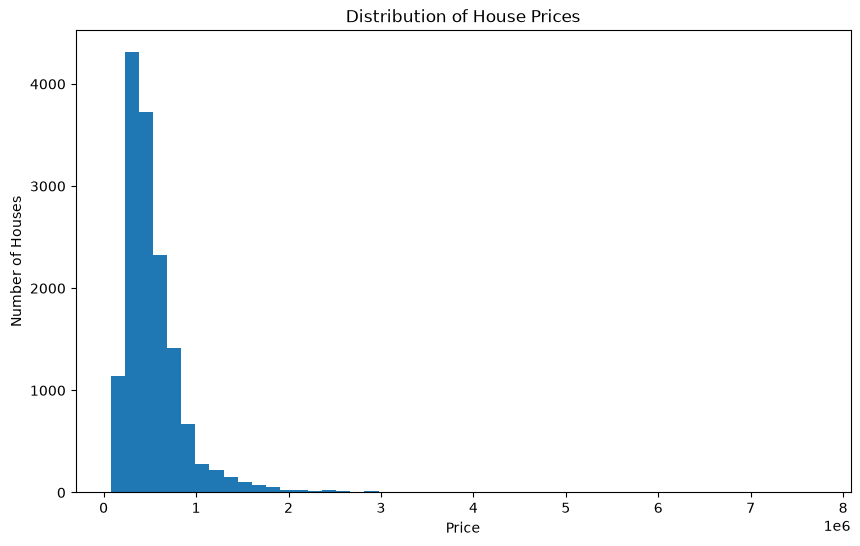

In [ ]:
# 18) ANALYZE PRICE DISTRIBUTION
# Calculate skewness
price_skewness = y.skew()

print("========== PRICE DISTRIBUTION ==========")
print(f"Price Skewness: {price_skewness:.4f}")

print("\nPrice statistics:")
print(y.describe())


# Plot price distribution
plt.figure(figsize=(10, 6))

plt.hist(y, bins=50)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

In [113]:
# ============================================
# STEP 19: LOG-TRANSFORM TARGET
# ============================================

# --------------------------------------------
# Create log-transformed target
# --------------------------------------------

y_log = np.log1p(y)


# --------------------------------------------
# Split the log target using the SAME
# train/test split
# --------------------------------------------

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)


# --------------------------------------------
# Create Random Forest
# --------------------------------------------

log_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


# --------------------------------------------
# Train model
# --------------------------------------------

log_model.fit(X_train_log, y_train_log)


# --------------------------------------------
# Predict log prices
# --------------------------------------------

y_pred_log = log_model.predict(X_test_log)


# --------------------------------------------
# Convert predictions back to original
# price scale
# --------------------------------------------

y_pred_log_original = np.expm1(y_pred_log)


# --------------------------------------------
# Evaluate using ORIGINAL prices
# --------------------------------------------

log_r2 = r2_score(y_test, y_pred_log_original)

log_mae = mean_absolute_error(
    y_test,
    y_pred_log_original
)

log_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_log_original
    )
)


print("========== LOG-TARGET RANDOM FOREST ==========")

print(f"R² Score: {log_r2:.4f}")
print(f"R² Score (%): {log_r2 * 100:.2f}%")
print(f"MAE: {log_mae:,.2f}")
print(f"RMSE: {log_rmse:,.2f}")

========== LOG-TARGET RANDOM FOREST ==========
R² Score: 0.8611
R² Score (%): 86.11%
MAE: 69,443.81
RMSE: 139,921.56


In [114]:
# STEP 20: FEATURE IMPORTANCE ANALYSIS
# Train the baseline model
baseline_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": baseline_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("========== FEATURE IMPORTANCE ==========")

print(feature_importance.to_string(index=False))

========== FEATURE IMPORTANCE ==========
                              Feature  Importance
                          living area    0.346629
                   grade of the house    0.232991
                            Lattitude    0.151355
                            Longitude    0.064222
                    living_area_renov    0.032731
Area of the house(excluding basement)    0.031092
                   waterfront present    0.029990
                           Built Year    0.020181
                          Postal Code    0.015709
                      number of views    0.013062
                       lot_area_renov    0.012160
                             lot area    0.011472
                  number of bathrooms    0.009864
            Distance from the airport    0.006700
                 Area of the basement    0.005642
                           Sale_Month    0.004243
                   number of bedrooms    0.003268
               condition of the house    0.002851
         

In [115]:
print("========== TOP 10 FEATURES ==========")

print(
    feature_importance.head(10).to_string(index=False)
)

========== TOP 10 FEATURES ==========
                              Feature  Importance
                          living area    0.346629
                   grade of the house    0.232991
                            Lattitude    0.151355
                            Longitude    0.064222
                    living_area_renov    0.032731
Area of the house(excluding basement)    0.031092
                   waterfront present    0.029990
                           Built Year    0.020181
                          Postal Code    0.015709
                      number of views    0.013062


In [119]:
# 20.1) FEATURE ENGINEERING

X_engineered = X.copy()

# House age when it was sold
X_engineered["House_Age"] = X_engineered["Sale_Year"] - X_engineered["Built Year"]

# Years since renovation
X_engineered["Years_Since_Renovation"] = (
    X_engineered["Sale_Year"] - X_engineered["Renovation Year"]
)

# Whether the house was ever renovated
X_engineered["Was_Renovated"] = (
    X_engineered["Renovation Year"] > 0
).astype(int)

# Avoid negative values if any unusual records exist
X_engineered["House_Age"] = X_engineered["House_Age"].clip(lower=0)
X_engineered["Years_Since_Renovation"] = (
    X_engineered["Years_Since_Renovation"].clip(lower=0)
)

print("Original number of features:", X.shape[1])
print("Engineered number of features:", X_engineered.shape[1])

print("\nNew features:")
print([
    "House_Age",
    "Years_Since_Renovation",
    "Was_Renovated"
])

Original number of features: 22
Engineered number of features: 25

New features:
['House_Age', 'Years_Since_Renovation', 'Was_Renovated']


In [120]:
# 20.2) TRAIN/TEST SPLIT

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered,
    y,
    test_size=0.20,
    random_state=42
)

print("Training shape:", X_train_eng.shape)
print("Testing shape:", X_test_eng.shape)

Training shape: (11696, 25)
Testing shape: (2924, 25)


In [121]:
# 20.3) ENGINEERED RANDOM FOREST

engineered_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

engineered_model.fit(X_train_eng, y_train_eng)

y_pred_eng = engineered_model.predict(X_test_eng)

r2_eng = r2_score(y_test_eng, y_pred_eng)
mae_eng = mean_absolute_error(y_test_eng, y_pred_eng)
rmse_eng = np.sqrt(mean_squared_error(y_test_eng, y_pred_eng))

print("========== ENGINEERED MODEL ==========")
print(f"R² Score: {r2_eng:.4f}")
print(f"R² Score (%): {r2_eng * 100:.2f}%")
print(f"MAE: {mae_eng:,.2f}")
print(f"RMSE: {rmse_eng:,.2f}")

========== ENGINEERED MODEL ==========
R² Score: 0.8721
R² Score (%): 87.21%
MAE: 68,877.98
RMSE: 134,243.16


In [123]:
# 21) FINAL MODEL

final_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train using the original feature set
final_model.fit(X_train, y_train)

# Make predictions
final_predictions = final_model.predict(X_test)

print("Final model training completed!")

print("\nModel:")
print(final_model)

Final model training completed!

Model:
RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)


In [124]:
# 22) FINAL MODEL EVALUATION

final_r2 = r2_score(y_test, final_predictions)
final_mae = mean_absolute_error(y_test, final_predictions)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

print("========== FINAL MODEL EVALUATION ==========")
print(f"R² Score:       {final_r2:.4f}")
print(f"R² Score (%):   {final_r2 * 100:.2f}%")
print(f"MAE:            {final_mae:,.2f}")
print(f"MSE:            {final_mse:,.2f}")
print(f"RMSE:           {final_rmse:,.2f}")

========== FINAL MODEL EVALUATION ==========
R² Score:       0.8747
R² Score (%):   87.47%
MAE:            68,636.02
MSE:            17,660,748,550.08
RMSE:           132,893.75


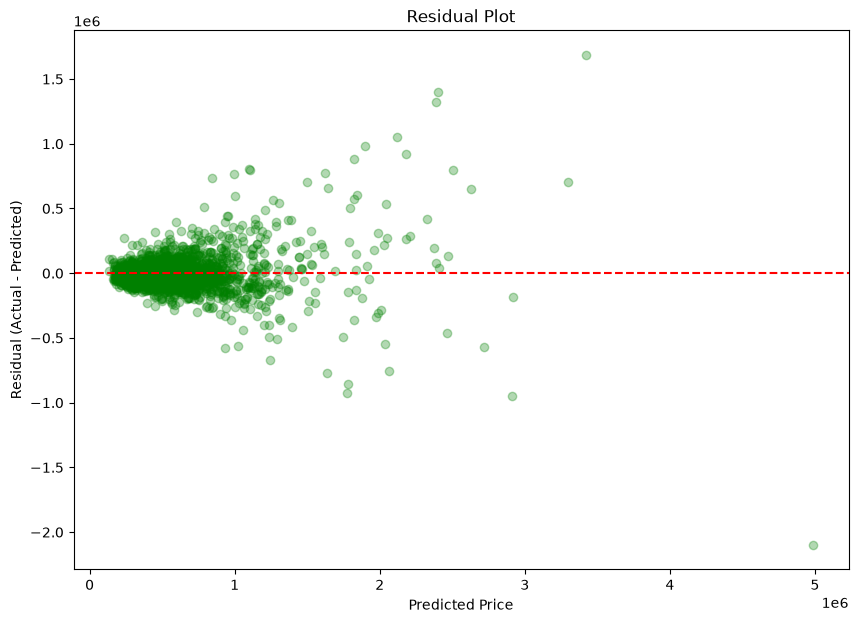

In [127]:
# 23) RESIDUAL ANALYSIS
residuals = y_test - final_predictions

plt.figure(figsize=(10, 7))

plt.scatter(
    final_predictions,
    residuals,
    color="green",
    alpha=0.3
)

plt.axhline(
    y=0,
    color = "red",
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")

plt.show()

In [129]:
# 24) SAVE FINAL MODEL
import joblib

joblib.dump(final_model, "house_price_random_forest.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [130]:

# 25.1) MODEL INPUT FEATURES

print("Number of features:", len(X.columns))

print("\nFeatures required by the model:")
for i, feature in enumerate(X.columns, start=1):
    print(f"{i}. {feature}")

Number of features: 22

Features required by the model:
1. number of bedrooms
2. number of bathrooms
3. living area
4. lot area
5. number of floors
6. waterfront present
7. number of views
8. condition of the house
9. grade of the house
10. Area of the house(excluding basement)
11. Area of the basement
12. Built Year
13. Renovation Year
14. Postal Code
15. Lattitude
16. Longitude
17. living_area_renov
18. lot_area_renov
19. Number of schools nearby
20. Distance from the airport
21. Sale_Year
22. Sale_Month


In [132]:
# 27.2) HOUSE PRICE PREDICTION FUNCTION

def predict_house_price(
    bedrooms,
    bathrooms,
    living_area,
    lot_area,
    floors,
    waterfront,
    views,
    condition,
    grade,
    house_area_excl_basement,
    basement_area,
    built_year,
    renovation_year,
    postal_code,
    latitude,
    longitude,
    living_area_renov,
    lot_area_renov,
    schools_nearby,
    distance_airport,
    sale_year,
    sale_month
):
    
    # Create input data in exactly the same order
    house_data = pd.DataFrame([{
        "number of bedrooms": bedrooms,
        "number of bathrooms": bathrooms,
        "living area": living_area,
        "lot area": lot_area,
        "number of floors": floors,
        "waterfront present": waterfront,
        "number of views": views,
        "condition of the house": condition,
        "grade of the house": grade,
        "Area of the house(excluding basement)": house_area_excl_basement,
        "Area of the basement": basement_area,
        "Built Year": built_year,
        "Renovation Year": renovation_year,
        "Postal Code": postal_code,
        "Lattitude": latitude,
        "Longitude": longitude,
        "living_area_renov": living_area_renov,
        "lot_area_renov": lot_area_renov,
        "Number of schools nearby": schools_nearby,
        "Distance from the airport": distance_airport,
        "Sale_Year": sale_year,
        "Sale_Month": sale_month
    }])

    # Make prediction
    prediction = final_model.predict(house_data)[0]

    return prediction

In [133]:
# 27.3) TEST THE PREDICTION FUNCTION

predicted_price = predict_house_price(
    bedrooms=3,
    bathrooms=2.5,
    living_area=1800,
    lot_area=5000,
    floors=2,
    waterfront=0,
    views=0,
    condition=3,
    grade=8,
    house_area_excl_basement=1800,
    basement_area=0,
    built_year=2000,
    renovation_year=0,
    postal_code=98001,
    latitude=47.35,
    longitude=-122.20,
    living_area_renov=1800,
    lot_area_renov=5000,
    schools_nearby=2,
    distance_airport=30,
    sale_year=2014,
    sale_month=5
)

print(f"Predicted House Price: ${predicted_price:,.2f}")

Predicted House Price: $325,110.41
